# GEARS Baseline on Norman 2019 — GI-Stratified Evaluation

**Purpose**: Reproduce GEARS on the Norman 2019 benchmark with the same GI-stratified evaluation applied to scGPT, enabling direct model comparison.

**Key questions**:
1. Does GEARS beat the additive baseline on combinatorial perturbations?
2. Does GEARS fail differentially on high-GI-magnitude (non-additive) perturbations?
3. How does GEARS compare to scGPT across GI types and seen levels?

**Outputs**:
- `save/gears_norman_*/per_perturbation_results.csv` — matches scGPT format for `compare_models.ipynb`
- `save/gears_norman_*/gi_stratified_summary.csv`

**Environment**: Run in a conda env with GEARS installed (`from gears import PertData, GEARS`).  
Data splits use `seed=42` (simulation split) matching `obs['gears_split']` in the h5ad.

## 1. Environment Setup

In [1]:
import os, sys, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, mannwhitneyu
from scipy import sparse
from sklearn.linear_model import LinearRegression

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10

from gears import PertData, GEARS

print("GEARS imported successfully.")

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/conda_envs/GEARS/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/conda_envs/GEARS/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/conda_envs/GEARS/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/conda_envs/GEARS/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/conda_envs/GEARS/lib/python3.9/site-packages/traitlets/traitlets.py", line 649, in get
    value = self._validate(obj, default)
  File "/conda_envs/GEARS/lib/python3.9/site-packages

GEARS imported successfully.


In [2]:
# GPU selection — pick the least-used GPU
import subprocess
result = subprocess.run(
    ['nvidia-smi', '--query-gpu=index,memory.used', '--format=csv,noheader,nounits'],
    capture_output=True, text=True
)
gpu_mem = [(int(line.split(',')[0]), int(line.split(',')[1].strip()))
           for line in result.stdout.strip().split('\n') if line]
best_gpu = min(gpu_mem, key=lambda x: x[1])[0]
os.environ['CUDA_VISIBLE_DEVICES'] = str(best_gpu)
print(f"Using GPU {best_gpu}. Memory usage: {gpu_mem}")

Using GPU 1. Memory usage: [(0, 6749), (1, 0), (2, 0), (3, 0), (4, 0), (5, 0), (6, 0), (7, 0)]


## 2. Load Data via GEARS PertData

GEARS requires its own PyG-format dataset. We use the pre-built local copy at
`../../data/raw_download/GEARS_data/norman/` and regenerate the `simulation` split
with `seed=42` — the same seed used to produce `obs['gears_split']` in the h5ad.

In [3]:
GEARS_DATA_DIR = '../../data/raw_download/GEARS_data/'
H5AD_PATH = '../../data/splits/norman_2019_raw_sparse_with_splits_original_from_GEARS.h5ad'
SPLIT_SEED = 42

pert_data = PertData(GEARS_DATA_DIR)
pert_data.load(data_name='norman')
pert_data.prepare_split(split='simulation', seed=SPLIT_SEED)
pert_data.get_dataloader(batch_size=256, test_batch_size=512)

# GEARS does not store split labels in adata.obs — use set2conditions
for split in ['train', 'val', 'test']:
    print(f"{split}: {len(pert_data.set2conditions[split])} conditions")

Found local copy...
Found local copy...
Found local copy...
These perturbations are not in the GO graph and their perturbation can thus not be predicted
['RHOXF2BB+ctrl' 'LYL1+IER5L' 'ctrl+IER5L' 'KIAA1804+ctrl' 'IER5L+ctrl'
 'RHOXF2BB+ZBTB25' 'RHOXF2BB+SET']
Local copy of pyg dataset is detected. Loading...
Done!
Local copy of split is detected. Loading...
Simulation split test composition:
combo_seen0:5
combo_seen1:55
combo_seen2:17
unseen_single:37
Done!
Creating dataloaders....
Done!


here1
train: 130 conditions
val: 33 conditions
test: 114 conditions


In [4]:
# Cross-check: splits from PertData match the h5ad gears_split column
adata_ref = sc.read_h5ad(H5AD_PATH)

for split_name in ['train', 'val', 'test']:
    gears_conds = set(pert_data.set2conditions[split_name])
    h5ad_conds = set(
        adata_ref.obs.loc[adata_ref.obs['gears_split'] == split_name, 'condition'].unique()
    )
    overlap = len(gears_conds & h5ad_conds)
    print(f"{split_name}: GEARS={len(gears_conds)}, h5ad={len(h5ad_conds)}, overlap={overlap}")

del adata_ref

train: GEARS=130, h5ad=130, overlap=130
val: GEARS=33, h5ad=33, overlap=33
test: GEARS=114, h5ad=114, overlap=114


## 3. GEARS Model Setup

In [5]:
import torch
device = 'cuda:0'  # CUDA_VISIBLE_DEVICES already set above

gears_model = GEARS(
    pert_data,
    device=device,
    weight_bias_track=False,
    proj_name='gears_norman',
    exp_name='gears_norman_seed42',
)
gears_model.model_initialize(hidden_size=64)

print("Tunable parameters:")
print(gears_model.tunable_parameters())

Found local copy...


Tunable parameters:
{'hidden_size': 'hidden dimension, default 64', 'num_go_gnn_layers': 'number of GNN layers for GO graph, default 1', 'num_gene_gnn_layers': 'number of GNN layers for co-expression gene graph, default 1', 'decoder_hidden_size': 'hidden dimension for gene-specific decoder, default 16', 'num_similar_genes_go_graph': 'number of maximum similar K genes in the GO graph, default 20', 'num_similar_genes_co_express_graph': 'number of maximum similar K genes in the co expression graph, default 20', 'coexpress_threshold': 'pearson correlation threshold when constructing coexpression graph, default 0.4', 'uncertainty': 'whether or not to turn on uncertainty mode, default False', 'uncertainty_reg': 'regularization term to balance uncertainty loss and prediction loss, default 1', 'direction_lambda': 'regularization term to balance direction loss and prediction loss, default 1'}


## 4. Training

In [6]:
save_dir = Path(f"./save/gears_norman_seed{SPLIT_SEED}-{time.strftime('%b%d-%H-%M')}/")
save_dir.mkdir(parents=True, exist_ok=True)
print(f"Save directory: {save_dir}")

EPOCHS = 20
LR = 1e-3

t0 = time.time()
gears_model.train(epochs=EPOCHS, lr=LR)
print(f"\nTraining complete in {(time.time()-t0)/60:.1f} min")

Start Training...


Save directory: save/gears_norman_seed42-Mar06-16-35


Epoch 1 Step 1 Train Loss: 0.5344
Epoch 1 Step 51 Train Loss: 0.4908
Epoch 1 Step 101 Train Loss: 0.5249
Epoch 1 Step 151 Train Loss: 0.5147
Epoch 1: Train Overall MSE: 0.0054 Validation Overall MSE: 0.0077. 
Train Top 20 DE MSE: 0.1008 Validation Top 20 DE MSE: 0.1917. 
Epoch 2 Step 1 Train Loss: 0.5461
Epoch 2 Step 51 Train Loss: 0.5168
Epoch 2 Step 101 Train Loss: 0.5175
Epoch 2 Step 151 Train Loss: 0.4758
Epoch 2: Train Overall MSE: 0.0040 Validation Overall MSE: 0.0064. 
Train Top 20 DE MSE: 0.0792 Validation Top 20 DE MSE: 0.2053. 
Epoch 3 Step 1 Train Loss: 0.5104
Epoch 3 Step 51 Train Loss: 0.5018
Epoch 3 Step 101 Train Loss: 0.5275
Epoch 3 Step 151 Train Loss: 0.5447
Epoch 3: Train Overall MSE: 0.0037 Validation Overall MSE: 0.0063. 
Train Top 20 DE MSE: 0.0594 Validation Top 20 DE MSE: 0.1831. 
Epoch 4 Step 1 Train Loss: 0.5859
Epoch 4 Step 51 Train Loss: 0.5410
Epoch 4 Step 101 Train Loss: 0.5289
Epoch 4 Step 151 Train Loss: 0.5379
Epoch 4: Train Overall MSE: 0.0035 Validati


Training complete in 75.7 min


In [7]:
# Save model
gears_model.save_model(str(save_dir / 'gears_model'))
print(f"Model saved to {save_dir / 'gears_model'}")

Model saved to save/gears_norman_seed42-Mar06-16-35/gears_model


## 5. Per-Perturbation Evaluation

Iterate over all **test-split conditions** and collect:
- predicted mean expression (from `gears_model.predict()`)
- true mean expression (from h5ad, normalized)
- control mean expression (from h5ad, normalized)

Then compute PCC on top-20 DE genes (same metric as scGPT eval).

> Note: GEARS predictions and the h5ad are both in `log1p(CP10k)` space — units match.

In [8]:
# Load the h5ad directly and normalize — same pipeline as scGPT eval,
# so GI annotations computed here are on an identical gene space (5045 genes).
adata = sc.read_h5ad(H5AD_PATH)
if 'gene_name' in adata.var.columns:
    adata.var.set_index('gene_name', inplace=True)
    adata.var_names_make_unique()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
gene_names = adata.var_names.tolist()

# Control mean (all control cells — matches scGPT eval)
ctrl_mask = adata.obs['condition'] == 'ctrl'
X_ctrl = adata[ctrl_mask].X
if sparse.issparse(X_ctrl):
    X_ctrl = X_ctrl.toarray()
ctrl_mean = X_ctrl.mean(axis=0).flatten()

# Per-condition mean expression
conditions = adata.obs['condition'].unique()
cond_means = {}
cond_ncells = {}
for cond in conditions:
    mask = adata.obs['condition'] == cond
    X = adata[mask].X
    if sparse.issparse(X):
        X = X.toarray()
    cond_means[cond] = X.mean(axis=0).flatten()
    cond_ncells[cond] = int(mask.sum())

print(f"Genes: {len(gene_names)}, Conditions: {len(conditions)}")
print(f"Control cells: {ctrl_mask.sum()}")

Genes: 5045, Conditions: 277
Control cells: 7353


In [9]:
def parse_condition(cond):
    """Parse condition string. Returns (gene_a, gene_b, is_combo)."""
    if '+' not in cond:
        return cond, None, False
    parts = cond.split('+')
    if len(parts) != 2:
        return cond, None, False
    a, b = parts
    if a == 'ctrl' and b == 'ctrl':
        return None, None, False
    if a == 'ctrl':
        return b, None, False
    if b == 'ctrl':
        return a, None, False
    return a, b, True


def get_gears_prediction(model, condition):
    """
    Get GEARS predicted mean expression for a condition string
    like 'CEBPE+RUNX1T1' or 'ARID1A+ctrl'.
    Returns 1D array of shape (n_genes,) or None if ctrl.
    """
    if condition == 'ctrl':
        return None
    ga, gb, is_combo = parse_condition(condition)
    if ga is None:
        return None
    gene_list = [ga] if not is_combo else [ga, gb]
    result = model.predict([gene_list])
    # result keys vary: single → gene name, combo → 'gA_gB' or 'gB_gA'
    assert len(result) == 1, f"Expected 1 prediction, got {list(result.keys())}"
    return list(result.values())[0]

In [10]:
# Run inference on all TEST conditions
test_conditions = list(pert_data.set2conditions['test'])
# Remove 'ctrl' if present
test_conditions = [c for c in test_conditions if c != 'ctrl']
print(f"Test conditions: {len(test_conditions)}")

per_pert_results = []
failed = []

for cond in test_conditions:
    try:
        # Prediction
        pred_expr = get_gears_prediction(gears_model, cond)
        if pred_expr is None:
            continue
        
        # Ground truth
        if cond not in cond_means:
            failed.append(cond)
            continue
        truth_expr = cond_means[cond]
        n_cells = cond_ncells[cond]
        
        # Deltas from control
        pred_delta = pred_expr - ctrl_mean
        truth_delta = truth_expr - ctrl_mean
        
        # Top-20 DE genes (by absolute truth delta)
        top20_idx = np.argsort(np.abs(truth_delta))[-20:]
        
        # PCC on top-20
        r_top20, _ = pearsonr(pred_delta[top20_idx], truth_delta[top20_idx])
        # PCC on all genes
        r_all, _ = pearsonr(pred_delta, truth_delta)
        # MSE on top-20
        mse_top20 = float(np.mean((pred_delta[top20_idx] - truth_delta[top20_idx]) ** 2))
        
        per_pert_results.append({
            'perturbation': cond,
            'model': 'GEARS',
            'pcc_top20': float(r_top20) if not np.isnan(r_top20) else np.nan,
            'pcc_all': float(r_all) if not np.isnan(r_all) else np.nan,
            'mse_top20': mse_top20,
            'n_cells': n_cells,
        })
    except Exception as e:
        failed.append(cond)
        print(f"  FAILED: {cond} — {e}")

results_df = pd.DataFrame(per_pert_results).dropna(subset=['pcc_top20'])
print(f"\nEvaluated: {len(results_df)} conditions ({len(failed)} failed/skipped)")
print(results_df[['pcc_top20', 'pcc_all', 'mse_top20']].describe())

Test conditions: 114

Evaluated: 114 conditions (0 failed/skipped)
        pcc_top20     pcc_all   mse_top20
count  114.000000  114.000000  114.000000
mean     0.711135    0.392394    0.931398
std      0.266881    0.209410    0.419977
min     -0.259774   -0.301798    0.245766
25%      0.616047    0.298199    0.596242
50%      0.792548    0.438183    0.889635
75%      0.902748    0.542872    1.171734
max      0.990807    0.822855    2.004380


In [11]:
# Overall summary
print("="*55)
print("GEARS BASELINE RESULTS ON NORMAN 2019 (seed=42)")
print("="*55)
print(f"PCC (top-20 DE): {results_df['pcc_top20'].mean():.4f} "
      f"± {results_df['pcc_top20'].std():.4f}  "
      f"(median {results_df['pcc_top20'].median():.4f})")
print(f"PCC (all genes): {results_df['pcc_all'].mean():.4f}  ← inflated")
print(f"MSE (top-20 DE): {results_df['mse_top20'].mean():.4f}")
print(f"N perturbations: {len(results_df)}")

GEARS BASELINE RESULTS ON NORMAN 2019 (seed=42)
PCC (top-20 DE): 0.7111 ± 0.2669  (median 0.7925)
PCC (all genes): 0.3924  ← inflated
MSE (top-20 DE): 0.9314
N perturbations: 114


## 6. GI Classification

Self-contained GI computation from the normalized adata (same methodology as scGPT eval notebook).
If the pre-computed CSV from the scGPT run exists, load it instead.

In [12]:
import glob as glob_module

# Try to load pre-computed GI annotations from the scGPT eval run
existing_gi_csvs = sorted(glob_module.glob(
    "../scGPT/save/dev_perturb_norman_*/norman_gi_annotations_computed.csv"
))

if existing_gi_csvs:
    gi_df = pd.read_csv(existing_gi_csvs[-1])
    print(f"Loaded pre-computed GI annotations: {existing_gi_csvs[-1]}")
    print(f"  {len(gi_df)} combos, types: {gi_df['gi_type'].value_counts().to_dict()}")
    RECOMPUTE_GI = False
else:
    print("No pre-computed GI annotations found — will recompute from adata.")
    RECOMPUTE_GI = True

Loaded pre-computed GI annotations: ../scGPT/save/dev_perturb_norman_leakfix-Mar05-20-28/norman_gi_annotations_computed.csv
  128 combos, types: {'suppressive': 49, 'synergistic': 47, 'additive': 32}


In [13]:
if RECOMPUTE_GI:
    # Recompute GI from GEARS adata (normalized expression)
    # This mirrors the exact methodology from S1_2c_evaluate_scgpt_gi_stratified_v2.ipynb
    
    cond_deltas = {c: cond_means[c] - ctrl_mean for c in cond_means}
    single_deltas = {}
    for cond in conditions:
        ga, gb, is_combo = parse_condition(cond)
        if ga is not None and not is_combo:
            single_deltas[ga] = cond_deltas[cond]

    combos_df = pd.DataFrame([
        {'condition': c,
         'gene_a': parse_condition(c)[0],
         'gene_b': parse_condition(c)[1]}
        for c in conditions if parse_condition(c)[2]
    ])

    gi_records = []
    for _, row in combos_df.iterrows():
        cond = row['condition']
        ga, gb = row['gene_a'], row['gene_b']
        if ga not in single_deltas or gb not in single_deltas:
            continue

        delta_ab = cond_deltas[cond]
        delta_a = single_deltas[ga]
        delta_b = single_deltas[gb]
        additive_expect = delta_a + delta_b
        gi_vector = delta_ab - additive_expect

        top20_idx = np.argsort(np.abs(delta_ab))[-20:]
        gi_top20 = gi_vector[top20_idx]

        X_reg = np.column_stack([delta_a, delta_b])
        reg = LinearRegression(fit_intercept=False).fit(X_reg, delta_ab)
        c1, c2 = reg.coef_
        epsilon = delta_ab - reg.predict(X_reg)
        ss_res = np.sum(epsilon ** 2)
        ss_tot = np.sum((delta_ab - delta_ab.mean()) ** 2)
        r2 = 1 - ss_res / (ss_tot + 1e-10)

        mse_add_t20 = np.mean((additive_expect[top20_idx] - delta_ab[top20_idx]) ** 2)
        r_add_t20, _ = pearsonr(additive_expect[top20_idx], delta_ab[top20_idx])

        gi_records.append({
            'condition': cond, 'gene_a': ga, 'gene_b': gb,
            'gi_magnitude_top20': np.linalg.norm(gi_top20),
            'gi_mean_signed_top20': np.mean(gi_top20),
            'gi_magnitude_all': np.linalg.norm(gi_vector),
            'c1': c1, 'c2': c2, 'r2_additive': r2,
            'epsilon_norm': np.linalg.norm(epsilon),
            'epsilon_norm_top20': np.linalg.norm(epsilon[top20_idx]),
            'mse_additive_top20': mse_add_t20,
            'pcc_additive_top20': float(r_add_t20) if not np.isnan(r_add_t20) else 0.0,
        })

    gi_df_raw = pd.DataFrame(gi_records)

    gi_mag_q25 = gi_df_raw['gi_magnitude_top20'].quantile(0.25)
    gi_mag_q75 = gi_df_raw['gi_magnitude_top20'].quantile(0.75)
    r2_threshold = 0.5

    def classify_gi(row):
        if row['r2_additive'] < r2_threshold and row['epsilon_norm_top20'] > gi_mag_q75:
            return 'neomorphic'
        if row['gi_magnitude_top20'] <= gi_mag_q25:
            return 'additive'
        if row['gi_mean_signed_top20'] > 0:
            return 'synergistic'
        return 'suppressive'

    gi_df_raw['gi_type'] = gi_df_raw.apply(classify_gi, axis=1)
    gi_df = gi_df_raw
    print(f"GI computed for {len(gi_df)} combos")
    print(gi_df['gi_type'].value_counts())

## 7. Merge Results with GI Annotations

In [14]:
def is_combo(pert):
    if '+' not in pert:
        return False
    parts = pert.split('+')
    return len(parts) == 2 and parts[0] != 'ctrl' and parts[1] != 'ctrl'

results_df['is_combo'] = results_df['perturbation'].apply(is_combo)

# Build GI lookup (both gene orderings)
gi_lookup = {}
for _, row in gi_df.iterrows():
    gi_lookup[row['condition']] = row
    gi_lookup[f"{row['gene_b']}+{row['gene_a']}"] = row

merged_rows = []
for _, r in results_df.iterrows():
    pert = r['perturbation']
    base = r.to_dict()
    if pert in gi_lookup:
        gi_row = gi_lookup[pert]
        for col in ['gi_type', 'gi_magnitude_top20', 'r2_additive',
                    'epsilon_norm_top20', 'c1', 'c2',
                    'mse_additive_top20', 'pcc_additive_top20']:
            base[col] = gi_row[col]
    else:
        base['gi_type'] = 'single' if not r['is_combo'] else 'no_single_data'
        for col in ['gi_magnitude_top20', 'r2_additive', 'epsilon_norm_top20',
                    'c1', 'c2', 'mse_additive_top20', 'pcc_additive_top20']:
            base[col] = np.nan
    merged_rows.append(base)

eval_df = pd.DataFrame(merged_rows)
print(f"Merged: {len(eval_df)} total")
print(eval_df['gi_type'].value_counts())

Merged: 114 total
gi_type
single         37
suppressive    30
synergistic    28
additive       19
Name: count, dtype: int64


## 8. Seen-Level Annotation

In [15]:
train_conditions_set = set(pert_data.set2conditions['train'])

train_singles = set()
for cond in train_conditions_set:
    ga, gb, is_c = parse_condition(cond)
    if ga and not is_c:
        train_singles.add(ga)
    if is_c:
        train_singles.add(ga)
        train_singles.add(gb)

def get_seen_level(pert):
    ga, gb, is_c = parse_condition(pert)
    if not is_c:
        return 'single'
    return f"seen{int(ga in train_singles) + int(gb in train_singles)}"

eval_df['seen_level'] = eval_df['perturbation'].apply(get_seen_level)

print("Results by seen level:")
for level in ['seen0', 'seen1', 'seen2', 'single']:
    sub = eval_df[eval_df['seen_level'] == level]
    if len(sub) == 0:
        continue
    print(f"  {level:<8} | n={len(sub):3d} | "
          f"PCC = {sub['pcc_top20'].mean():.3f} ± {sub['pcc_top20'].std():.3f} "
          f"(median {sub['pcc_top20'].median():.3f})")

Results by seen level:
  seen0    | n= 10 | PCC = 0.619 ± 0.315 (median 0.736)
  seen1    | n= 52 | PCC = 0.793 ± 0.206 (median 0.871)
  seen2    | n= 15 | PCC = 0.802 ± 0.311 (median 0.904)
  single   | n= 37 | PCC = 0.585 ± 0.263 (median 0.612)


## 9. Stratified Results: GEARS vs Additive Baseline

In [16]:
combo_eval = eval_df[eval_df['gi_type'].isin(
    ['additive', 'synergistic', 'suppressive', 'neomorphic']
)].copy()

gi_order = ['additive', 'synergistic', 'suppressive', 'neomorphic']
gi_order_plot = [t for t in gi_order if t in combo_eval['gi_type'].values]

print("="*80)
print("STRATIFIED RESULTS: GEARS vs ADDITIVE BASELINE")
print("="*80)
print(f"{'GI Type':<15} {'n':>3}  {'GEARS PCC':>11} {'Additive PCC':>14} "
      f"{'GEARS MSE':>11} {'Additive MSE':>14}")
print("-"*80)

summary_rows = []
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    if len(sub) == 0:
        continue
    row = {
        'gi_type': gi_type, 'n': len(sub),
        'gears_pcc_mean': sub['pcc_top20'].mean(),
        'gears_pcc_std': sub['pcc_top20'].std(),
        'additive_pcc_mean': sub['pcc_additive_top20'].mean(),
        'additive_pcc_std': sub['pcc_additive_top20'].std(),
        'gears_mse_mean': sub['mse_top20'].mean(),
        'gears_mse_std': sub['mse_top20'].std(),
        'additive_mse_mean': sub['mse_additive_top20'].mean(),
        'additive_mse_std': sub['mse_additive_top20'].std(),
    }
    summary_rows.append(row)
    print(f"{gi_type:<15} {row['n']:>3}  "
          f"{row['gears_pcc_mean']:>5.3f}±{row['gears_pcc_std']:.3f}  "
          f"{row['additive_pcc_mean']:>6.3f}±{row['additive_pcc_std']:.3f}  "
          f"{row['gears_mse_mean']:>5.3f}±{row['gears_mse_std']:.3f}  "
          f"{row['additive_mse_mean']:>6.3f}±{row['additive_mse_std']:.3f}")

print("-"*80)
print(f"{'ALL COMBOS':<15} {len(combo_eval):>3}  "
      f"{combo_eval['pcc_top20'].mean():>5.3f}±{combo_eval['pcc_top20'].std():.3f}  "
      f"{combo_eval['pcc_additive_top20'].mean():>6.3f}±{combo_eval['pcc_additive_top20'].std():.3f}  "
      f"{combo_eval['mse_top20'].mean():>5.3f}±{combo_eval['mse_top20'].std():.3f}  "
      f"{combo_eval['mse_additive_top20'].mean():>6.3f}±{combo_eval['mse_additive_top20'].std():.3f}")

singles = eval_df[eval_df['gi_type'] == 'single']
if len(singles) > 0:
    print(f"{'SINGLES':<15} {len(singles):>3}  "
          f"{singles['pcc_top20'].mean():>5.3f}±{singles['pcc_top20'].std():.3f}  "
          f"{'N/A':>14}  "
          f"{singles['mse_top20'].mean():>5.3f}±{singles['mse_top20'].std():.3f}  "
          f"{'N/A':>14}")

summary_df = pd.DataFrame(summary_rows)

STRATIFIED RESULTS: GEARS vs ADDITIVE BASELINE
GI Type           n    GEARS PCC   Additive PCC   GEARS MSE   Additive MSE
--------------------------------------------------------------------------------
additive         19  0.619±0.361   0.976±0.011  0.843±0.465   0.029±0.011
synergistic      28  0.851±0.112   0.962±0.025  0.988±0.346   0.136±0.085
suppressive      30  0.795±0.217   0.959±0.028  0.882±0.419   0.213±0.284
--------------------------------------------------------------------------------
ALL COMBOS       77  0.772±0.248   0.964±0.024  0.911±0.405   0.139±0.196
SINGLES          37  0.585±0.263             N/A  0.974±0.452             N/A


## 10. Δ(GEARS − Additive) by GI Type

In [17]:
combo_eval['delta_pcc'] = combo_eval['pcc_top20'] - combo_eval['pcc_additive_top20']
combo_eval['delta_mse'] = combo_eval['mse_top20'] - combo_eval['mse_additive_top20']

print("="*70)
print("Δ(GEARS − Additive): negative PCC = GEARS worse than additive")
print("="*70)
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    if len(sub) == 0:
        continue
    print(f"{gi_type:<15} n={len(sub):>2}  "
          f"ΔPCC = {sub['delta_pcc'].mean():>+.3f} ± {sub['delta_pcc'].std():.3f}  "
          f"ΔMSE = {sub['delta_mse'].mean():>+.3f} ± {sub['delta_mse'].std():.3f}")

print(f"\n{'ALL':>15} n={len(combo_eval):>2}  "
      f"ΔPCC = {combo_eval['delta_pcc'].mean():>+.3f} ± {combo_eval['delta_pcc'].std():.3f}  "
      f"ΔMSE = {combo_eval['delta_mse'].mean():>+.3f} ± {combo_eval['delta_mse'].std():.3f}")

gears_wins_pcc = (combo_eval['delta_pcc'] > 0).sum()
print(f"\nGEARS beats additive (PCC): {gears_wins_pcc}/{len(combo_eval)} "
      f"({100*gears_wins_pcc/len(combo_eval):.1f}%)")

Δ(GEARS − Additive): negative PCC = GEARS worse than additive
additive        n=19  ΔPCC = -0.357 ± 0.362  ΔMSE = +0.814 ± 0.467
synergistic     n=28  ΔPCC = -0.111 ± 0.097  ΔMSE = +0.852 ± 0.348
suppressive     n=30  ΔPCC = -0.164 ± 0.212  ΔMSE = +0.669 ± 0.544

            ALL n=77  ΔPCC = -0.193 ± 0.247  ΔMSE = +0.771 ± 0.463

GEARS beats additive (PCC): 4/77 (5.2%)


In [18]:
# Mann-Whitney: additive vs synergistic/suppressive ΔPCC
add_delta = combo_eval.loc[combo_eval['gi_type'] == 'additive', 'delta_pcc']
for gi_type in ['synergistic', 'suppressive', 'neomorphic']:
    other_delta = combo_eval.loc[combo_eval['gi_type'] == gi_type, 'delta_pcc']
    if len(other_delta) > 0:
        stat, pval = mannwhitneyu(add_delta, other_delta, alternative='two-sided')
        print(f"ΔPCC additive vs {gi_type}: U={stat:.0f}, p={pval:.4f}")

ΔPCC additive vs synergistic: U=123, p=0.0020
ΔPCC additive vs suppressive: U=157, p=0.0089


## 11. GI Magnitude → Prediction Error

In [19]:
rho_mse, p_mse = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['mse_top20'])
rho_pcc, p_pcc = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['pcc_top20'])
rho_d, p_d = spearmanr(combo_eval['gi_magnitude_top20'], combo_eval['delta_mse'])

print(f"GI magnitude vs GEARS MSE:  Spearman ρ = {rho_mse:+.3f}, p = {p_mse:.2e}")
print(f"GI magnitude vs GEARS PCC:  Spearman ρ = {rho_pcc:+.3f}, p = {p_pcc:.2e}")
print(f"GI magnitude vs ΔMSE:       Spearman ρ = {rho_d:+.3f}, p = {p_d:.2e}")

GI magnitude vs GEARS MSE:  Spearman ρ = +0.146, p = 2.04e-01
GI magnitude vs GEARS PCC:  Spearman ρ = +0.398, p = 3.40e-04
GI magnitude vs ΔMSE:       Spearman ρ = -0.053, p = 6.49e-01


## 12. Visualizations

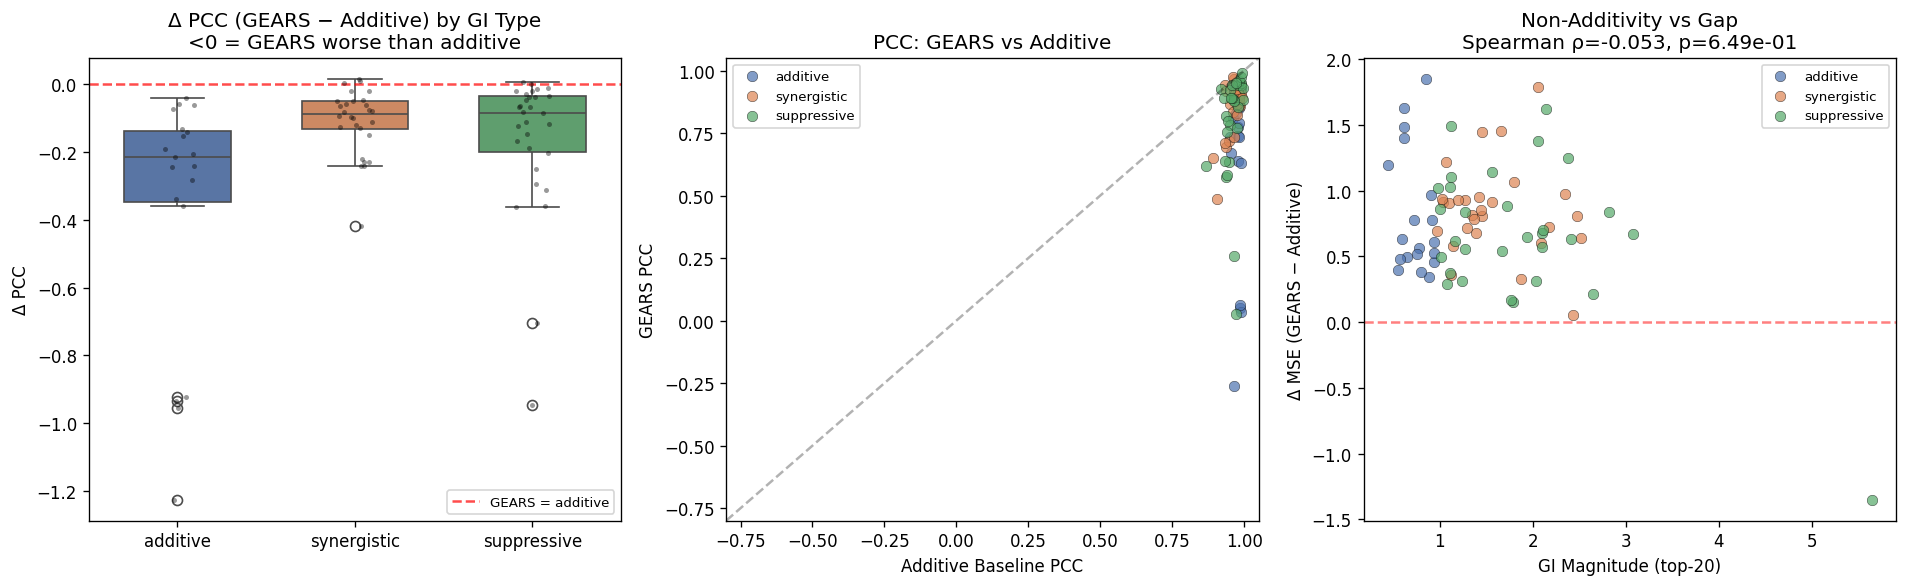

In [20]:
palette = {'additive': '#4C72B0', 'synergistic': '#DD8452',
           'suppressive': '#55A868', 'neomorphic': '#C44E52'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ΔPCC by GI type
sns.boxplot(data=combo_eval, x='gi_type', y='delta_pcc', order=gi_order_plot,
            palette=palette, ax=axes[0], width=0.6)
sns.stripplot(data=combo_eval, x='gi_type', y='delta_pcc', order=gi_order_plot,
              color='black', alpha=0.4, size=3, ax=axes[0])
axes[0].axhline(0, color='red', ls='--', alpha=0.7, label='GEARS = additive')
axes[0].set_title('Δ PCC (GEARS − Additive) by GI Type\n<0 = GEARS worse than additive')
axes[0].set_ylabel('Δ PCC')
axes[0].set_xlabel('')
axes[0].legend(fontsize=8)

# 2. GEARS vs Additive PCC scatter
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[1].scatter(sub['pcc_additive_top20'], sub['pcc_top20'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
lim = [-0.8, 1.05]
axes[1].plot(lim, lim, 'k--', alpha=0.3)
axes[1].set_xlim(lim); axes[1].set_ylim(lim)
axes[1].set_xlabel('Additive Baseline PCC')
axes[1].set_ylabel('GEARS PCC')
axes[1].set_title('PCC: GEARS vs Additive')
axes[1].legend(fontsize=8)

# 3. GI magnitude vs ΔMSE
for gi_type in gi_order_plot:
    sub = combo_eval[combo_eval['gi_type'] == gi_type]
    axes[2].scatter(sub['gi_magnitude_top20'], sub['delta_mse'],
                   c=palette[gi_type], label=gi_type, alpha=0.7,
                   edgecolors='k', linewidths=0.3, s=40)
axes[2].axhline(0, color='red', ls='--', alpha=0.5)
axes[2].set_xlabel('GI Magnitude (top-20)')
axes[2].set_ylabel('Δ MSE (GEARS − Additive)')
axes[2].set_title(f'Non-Additivity vs Gap\nSpearman ρ={rho_d:+.3f}, p={p_d:.2e}')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig(save_dir / 'gears_gi_stratified_eval.png', dpi=150, bbox_inches='tight')
plt.show()

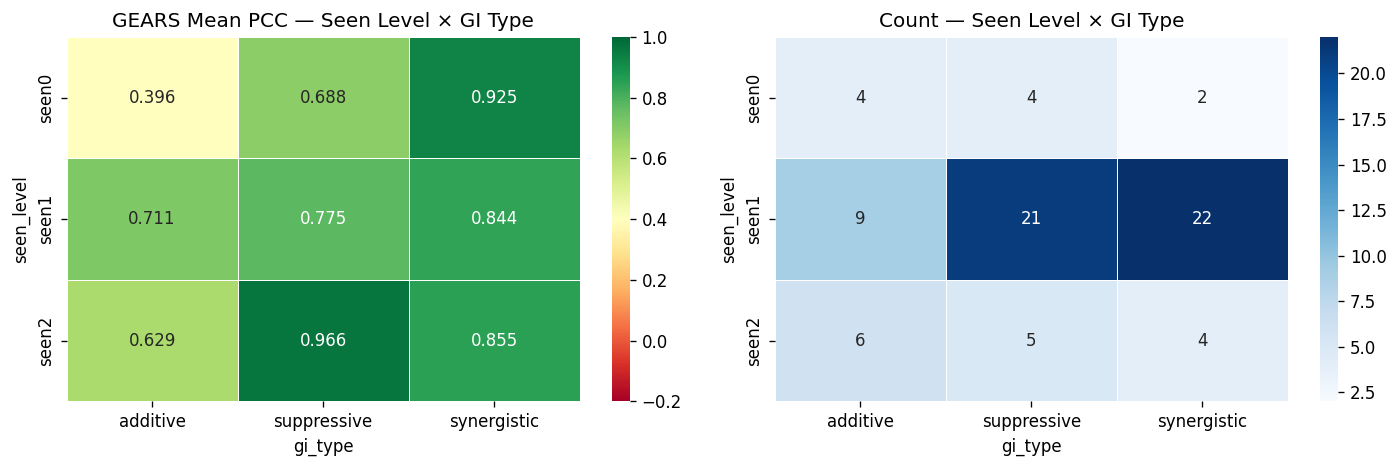

In [21]:
# Seen-level × GI-type heatmap
cross = eval_df[eval_df['gi_type'].isin(
    ['additive', 'synergistic', 'suppressive', 'neomorphic']
)].copy()

cross_pcc = cross.pivot_table(values='pcc_top20', index='seen_level',
                              columns='gi_type', aggfunc='mean')
cross_n = cross.pivot_table(values='perturbation', index='seen_level',
                            columns='gi_type', aggfunc='count')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cross_pcc, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[0],
            vmin=-0.2, vmax=1.0, linewidths=0.5)
axes[0].set_title('GEARS Mean PCC — Seen Level × GI Type')
sns.heatmap(cross_n.fillna(0).astype(int), annot=True, fmt='d', cmap='Blues',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Count — Seen Level × GI Type')
plt.tight_layout()
plt.savefig(save_dir / 'gears_cross_tab_seen_gi.png', dpi=150, bbox_inches='tight')
plt.show()

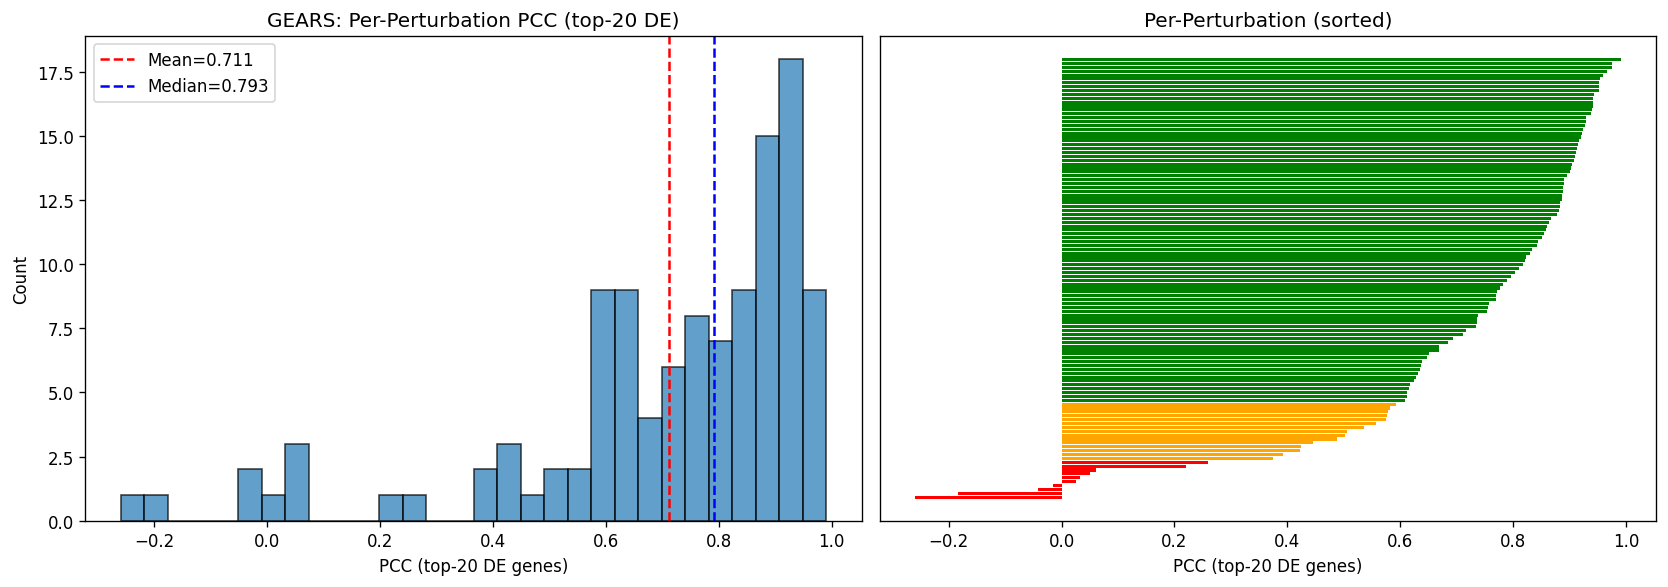


Worst 10 (targets for non-additive modeling):
  MAP2K3+SLC38A2                 PCC(top20) = -0.260  GI=additive
  ctrl+MAP2K6                    PCC(top20) = -0.184  GI=single
  MAP2K6+ctrl                    PCC(top20) = -0.042  GI=single
  TMSB4X+ctrl                    PCC(top20) = -0.015  GI=single
  MAP2K3+MAP2K6                  PCC(top20) = 0.026  GI=suppressive
  MAPK1+TGFBR2                   PCC(top20) = 0.033  GI=additive
  TMSB4X+BAK1                    PCC(top20) = 0.050  GI=additive
  MAP2K6+ELMSAN1                 PCC(top20) = 0.062  GI=additive
  CNNM4+ctrl                     PCC(top20) = 0.220  GI=single
  CNN1+MAPK1                     PCC(top20) = 0.260  GI=suppressive


In [22]:
# Per-perturbation PCC distribution
pcc_values = eval_df['pcc_top20'].dropna().values

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pcc_values, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(pcc_values), color='red', ls='--',
                label=f'Mean={np.mean(pcc_values):.3f}')
axes[0].axvline(np.median(pcc_values), color='blue', ls='--',
                label=f'Median={np.median(pcc_values):.3f}')
axes[0].set_xlabel('PCC (top-20 DE genes)')
axes[0].set_ylabel('Count')
axes[0].set_title('GEARS: Per-Perturbation PCC (top-20 DE)')
axes[0].legend()

sorted_df = eval_df.sort_values('pcc_top20').dropna(subset=['pcc_top20'])
colors = ['red' if v < 0.3 else 'orange' if v < 0.6 else 'green'
          for v in sorted_df['pcc_top20']]
axes[1].barh(range(len(sorted_df)), sorted_df['pcc_top20'].values,
             color=colors, height=0.8)
axes[1].set_xlabel('PCC (top-20 DE genes)')
axes[1].set_title('Per-Perturbation (sorted)')
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig(save_dir / 'gears_pcc_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWorst 10 (targets for non-additive modeling):")
for _, row in sorted_df.head(10).iterrows():
    print(f"  {row['perturbation']:30s} PCC(top20) = {row['pcc_top20']:.3f}  "
          f"GI={row.get('gi_type', 'N/A')}")

## 13. Save Results

In [23]:
# Per-perturbation CSV (matches scGPT format for compare_models.ipynb)
eval_df.to_csv(save_dir / 'per_perturbation_results.csv', index=False)

# GI annotations (reuse across models)
gi_df.to_csv(save_dir / 'norman_gi_annotations_computed.csv', index=False)

# GI-stratified summary
summary_df.to_csv(save_dir / 'gi_stratified_summary.csv', index=False)

print(f"Saved to {save_dir}/")
print(f"  per_perturbation_results.csv  ({len(eval_df)} rows)")
print(f"  norman_gi_annotations_computed.csv  ({len(gi_df)} rows)")
print(f"  gi_stratified_summary.csv")

Saved to save/gears_norman_seed42-Mar06-16-35/
  per_perturbation_results.csv  (114 rows)
  norman_gi_annotations_computed.csv  (128 rows)
  gi_stratified_summary.csv


## Summary

Key findings to record:

| Metric | GEARS | Additive | Δ |
|--------|-------|----------|---|
| All-combo PCC (top-20) | — | — | — |
| Additive GI PCC | — | — | — |
| Synergistic GI PCC | — | — | — |
| Suppressive GI PCC | — | — | — |

**Cross-model comparison**: Load `per_perturbation_results.csv` from both GEARS and scGPT
save dirs into `compare_models.ipynb`, which concatenates and plots side-by-side.